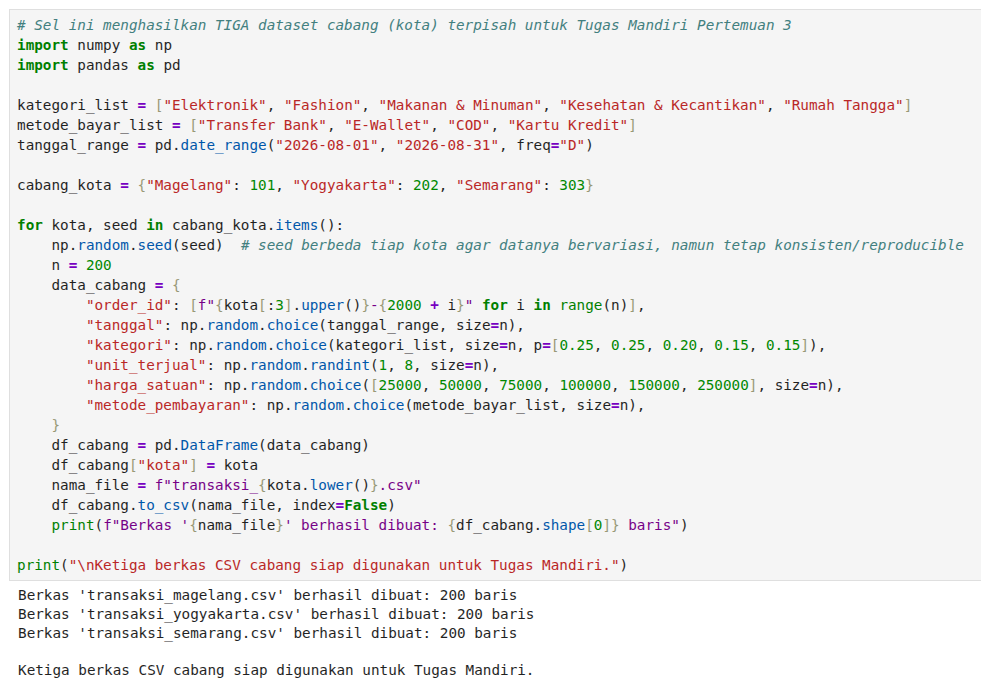

1. Membangun Struktur Direktori HDFS 

In [1]:
!hdfs dfs -mkdir -p /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw

In [2]:
!hdfs dfs -mkdir -p /home/bungakmal/Documents/praktikum-big_data/ecommerce/processed

2. Mengunggah data ke HDFS

In [1]:
!hdfs dfs -put transaksi_magelang.csv /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw

In [2]:
!hdfs dfs -put transaksi_yogyakarta.csv /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw

In [3]:
!hdfs dfs -put transaksi_semarang.csv /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw

In [5]:
# menampilkan isi direktori
!hdfs dfs -ls -h /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw

Found 3 items
-rw-r--r--   1 bungakmal supergroup     12.0 K 2026-09-05 17:01 /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 bungakmal supergroup     11.9 K 2026-09-05 17:03 /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 bungakmal supergroup     12.4 K 2026-09-05 17:03 /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_yogyakarta.csv


3. Membaca Kembali dan Menggabungkan Data dari HDFS

In [39]:
import pandas as pd

!hdfs dfs -get /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_magelang.csv magelang_hdfs.csv
!hdfs dfs -get /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_yogyakarta.csv yogyakarta_hdfs.csv
!hdfs dfs -get /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_semarang.csv semarang_hdfs.csv

dfmgl = pd.read_csv("magelang_hdfs.csv")
dfygy = pd.read_csv("yogyakarta_hdfs.csv")
dfsmr = pd.read_csv("semarang_hdfs.csv")

gabungan = pd.concat([dfmgl, dfygy, dfsmr])

print(gabungan['kota'].value_counts())

get: `magelang_hdfs.csv': File exists
get: `yogyakarta_hdfs.csv': File exists
get: `semarang_hdfs.csv': File exists
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


4. Mengolah dan Download Hasil ke Direktori processed

In [30]:
import pandas as pd

!hdfs dfs -get /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_magelang.csv magelang_hdfs.csv
!hdfs dfs -get /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_yogyakarta.csv yogyakarta_hdfs.csv
!hdfs dfs -get /home/bungakmal/Documents/praktikum-big_data/ecommerce/raw/transaksi_semarang.csv semarang_hdfs.csv

dfmgl = pd.read_csv("magelang_hdfs.csv")
dfygy = pd.read_csv("yogyakarta_hdfs.csv")
dfsmr = pd.read_csv("semarang_hdfs.csv")

gabungan = pd.concat([dfmgl, dfygy, dfsmr])
data_frame = pd.DataFrame(gabungan)
data_frame["total pendapatan"] = data_frame['unit_terjual'] * data_frame['harga_satuan']

gabungan['per kategori'] = gabungan['unit_terjual'] * gabungan['harga_satuan']
pendptn_kategori = gabungan.groupby("kategori")["per kategori"].sum()

pdp_kota = {
    "magelang" : sum(dfmgl['unit_terjual'] * dfmgl['harga_satuan']),
    "yogya" : sum(dfygy['unit_terjual'] * dfygy['harga_satuan']),
    "semarang" : sum(dfsmr['unit_terjual'] * dfsmr['harga_satuan'])
}

kedua = {
    "pendapatan per kategor" : pendptn_kategori,
    "pendapatan per kota" : pdp_kota
}

kedua_dataframe = pd.DataFrame(kedua)

nama_gabungan = f"data_gabungan_bersih.csv"
data_frame.to_csv(nama_gabungan)

ringks_kot = f"ringkasan_kota_kategori.csv"
kedua_dataframe.to_csv(ringks_kot)

!hdfs dfs -put data_gabungan_bersih.csv /home/bungakmal/Documents/praktikum-big_data/ecommerce/processed
!hdfs dfs -put ringkasan_kota_kategori.csv /home/bungakmal/Documents/praktikum-big_data/ecommerce/processed


get: `magelang_hdfs.csv': File exists
get: `yogyakarta_hdfs.csv': File exists
get: `semarang_hdfs.csv': File exists


5. Dokumentasi dan Refleksi
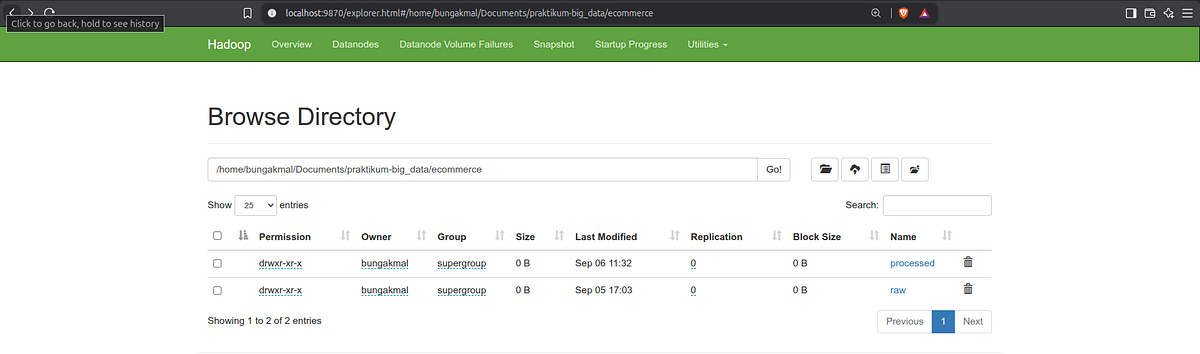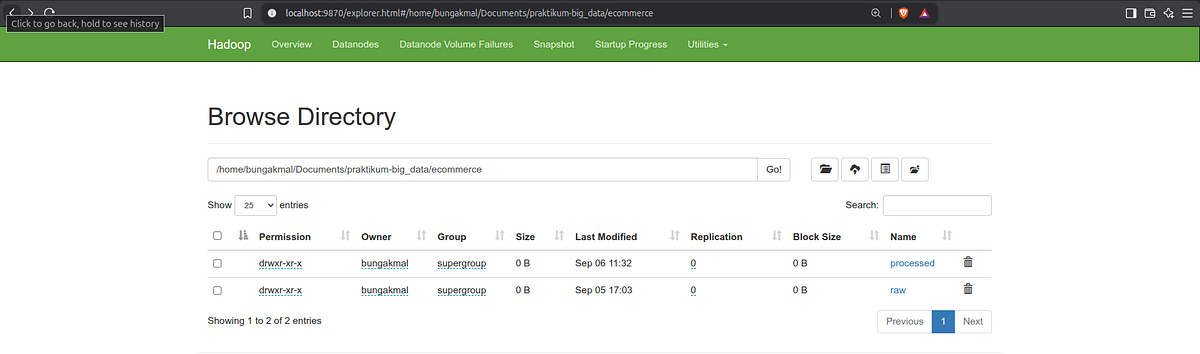

**ISI FOLDER RAW**
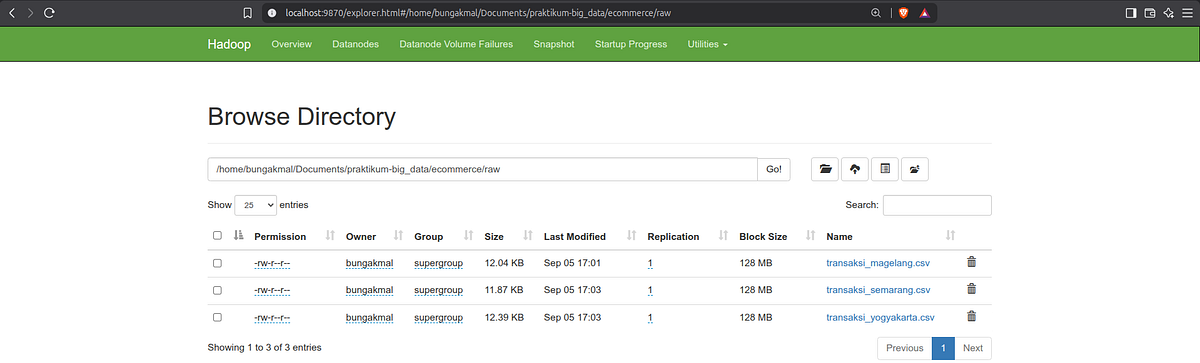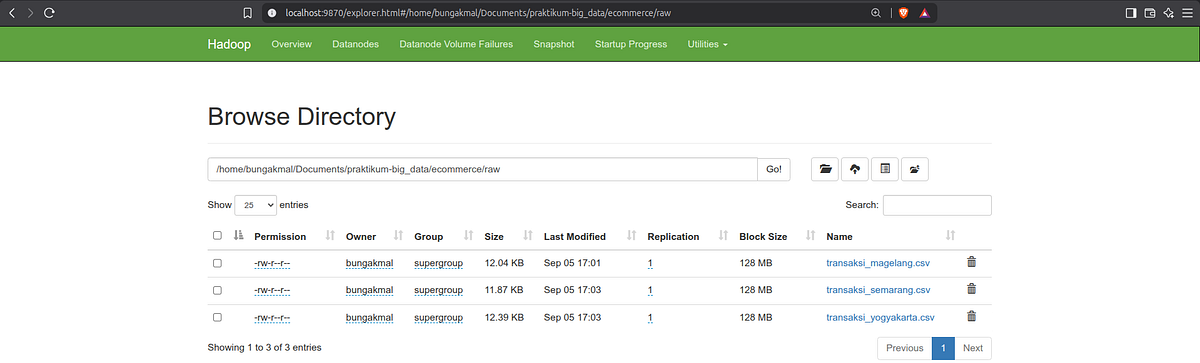

**ISI FOLDER PROCESSED**
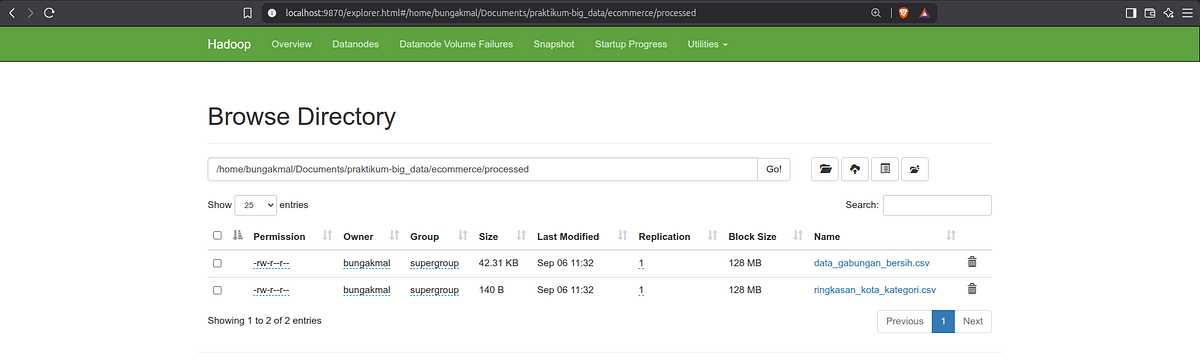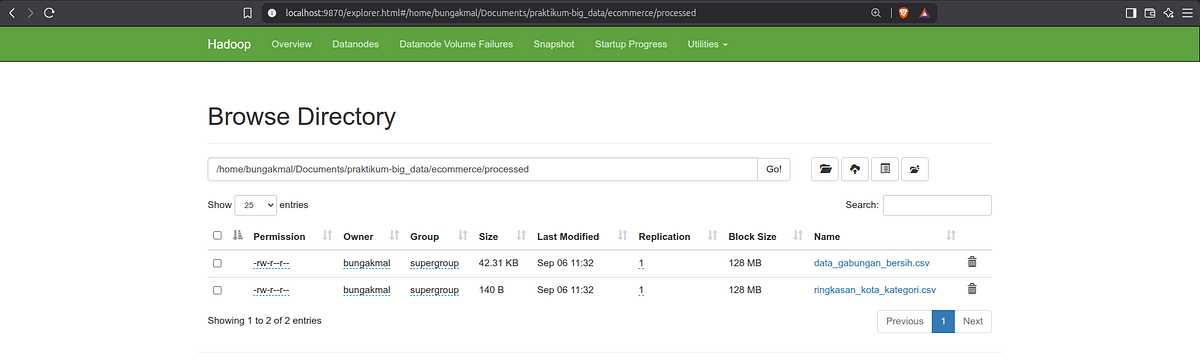

**isi data_gabungan_bersih.csv**
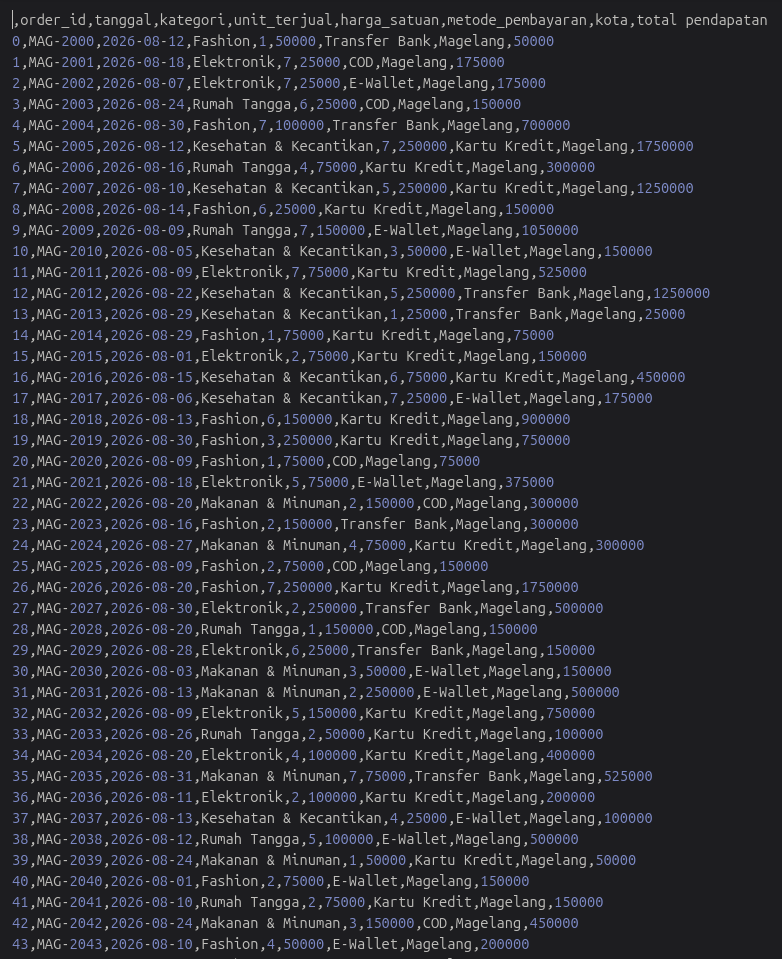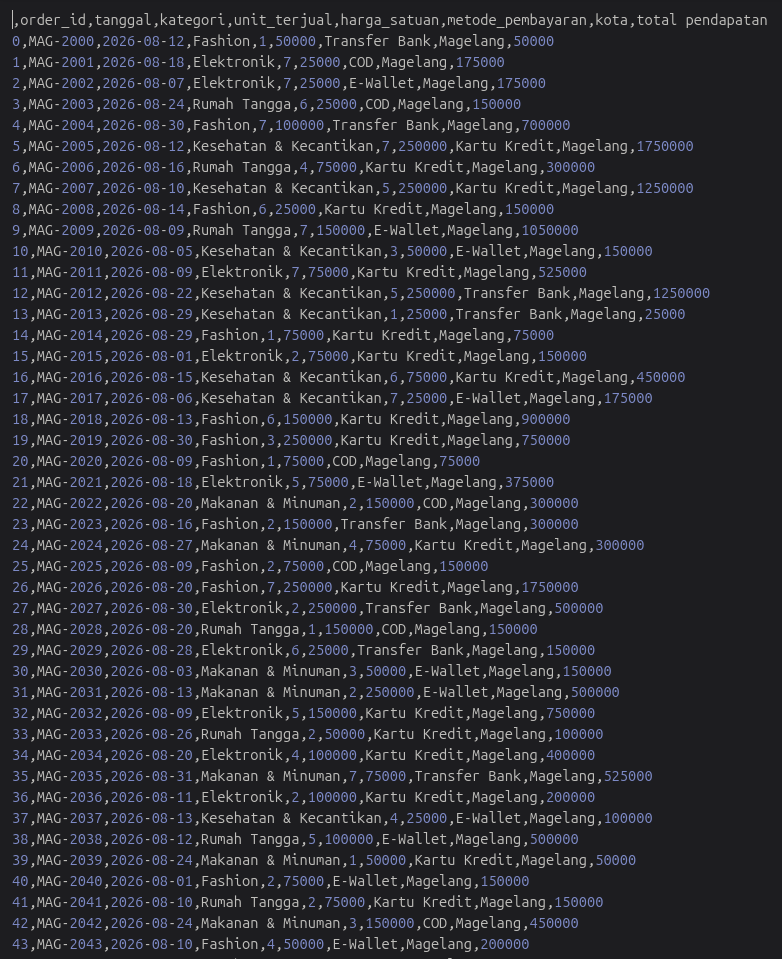

**isi ringkasan_kota_kategori.csv**
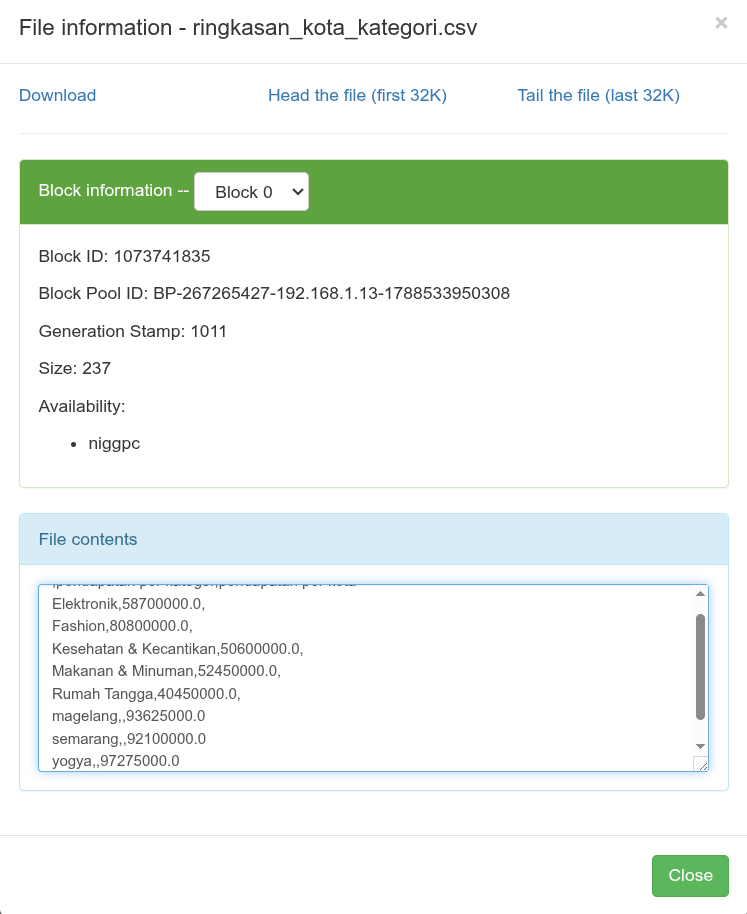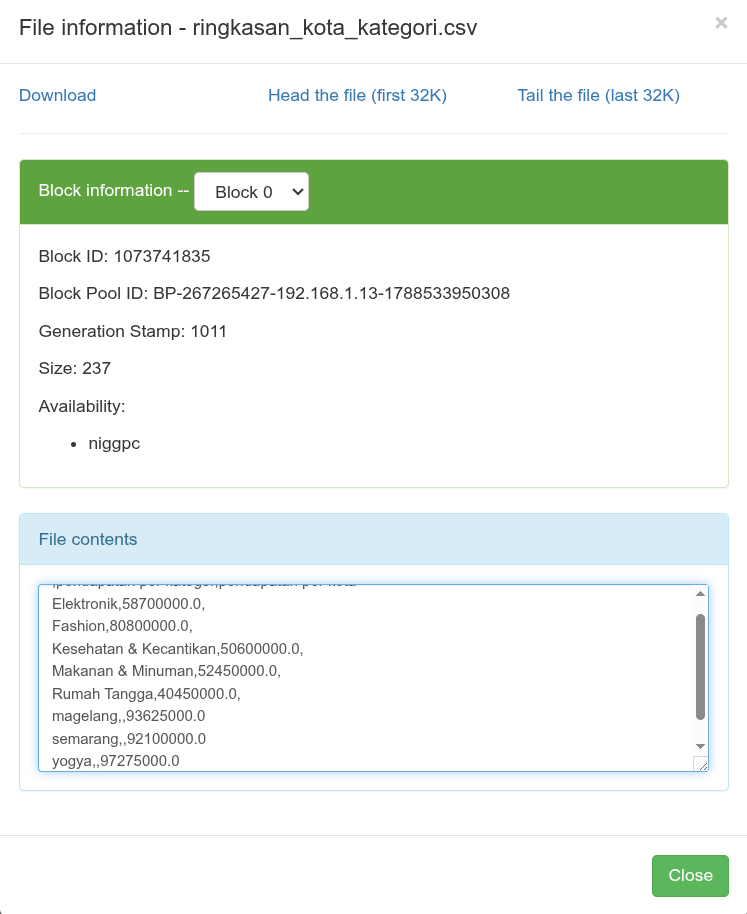


- Tulisan reflektif

**soal** : apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?

**jawab** : memisahkan antara data mentah dan data yang telah diolah adalah sebuah standar yang digunakan semua orang bahkan diluar dunia IT. Contohnya memisahkan hasil panen dengan hasil olahan. keuntungan yang diberikan dari mekanisme pemisahan ini memiiliki banyak manfaat contohnya mempermudah manajemen, mempermudah pencarian data, mempercepat proses pengolahan data dari raw menjadi informasi yang sudah matang dan masih banyak lagi. 
Jika membandingkan sistem pemisahan data mentah dan data yang sudah diolah dengan sistem yang menggabungkan keduanya itu memperlihatkan perbedaan antara langit dan bumi. Pada sistem penyimpanan dengan menggabungkan data mentah dan data yang sudah di olah, semua terlihat rapi, dan tidak menumpuk ke 1 folder. Ini berbeda dengan sistem menggabungkan keduanya ke 1 folder, data akan terlihat berantakan, dan akan menumpuk menjadi 1 folder yang akan menyebabkan sulitnya mengatur